In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/Iowa_Liquor_Sales_20260420.csv'
df = pd.read_csv(csv_path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_12514/3459657954.py:11: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County Number,County,...,Item Number,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons)
0,INV-47147800030,5/5/2022,4102,FAREWAY STORES #386 / AMES,619 BURNETT AVE,AMES,50010,POINT (-93.615432 42.027642),85.0,STORY,...,22215,WOODFORD RESERVE,12,750,$22.49,$33.74,2,$67.48,1.5,0.39
1,INV-47101000109,5/4/2022,2501,HY-VEE #2 / AMES,640 LINCOLNWAY,AMES,50010,NaN,85.0,STORY,...,68611,MCCORMICK IRISH CREAM,12,750,$6.66,$9.99,4,$39.96,3,0.79
2,INV-47148600033,5/5/2022,3973,MMDG SPIRITS / AMES,126A WELCH AVE,AMES,50014,POINT (-93.650131 42.021817),85.0,STORY,...,88296,PATRON SILVER,12,750,$28.00,$42.00,4,$168.00,3,0.79
3,INV-47101000056,5/4/2022,2501,HY-VEE #2 / AMES,640 LINCOLNWAY,AMES,50010,NaN,85.0,STORY,...,36978,NIKOLAI VODKA,6,"1,750",$6.92,$10.38,6,$62.28,10.5,2.77
4,INV-47148600061,5/5/2022,3973,MMDG SPIRITS / AMES,126A WELCH AVE,AMES,50014,POINT (-93.650131 42.021817),85.0,STORY,...,86390,MONTEZUMA TRIPLE SEC,12,"1,000",$2.13,$3.20,60,$192.00,60,15.85


In [ ]:
df['Sale (Dollars)'] = df['Sale (Dollars)'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace('(', '-', regex=False).str.replace(')', '', regex=False).astype(float)
df['Date'] = pd.to_datetime(df['Date'])
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245400 entries, 0 to 245399
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Invoice/Item Number    245400 non-null  object        
 1   Date                   245400 non-null  datetime64[ns]
 2   Store Number           245400 non-null  int64         
 3   Store Name             245400 non-null  object        
 4   Address                245400 non-null  object        
 5   City                   245400 non-null  object        
 6   Zip Code               245400 non-null  int64         
 7   Store Location         228565 non-null  object        
 8   County Number          32473 non-null   float64       
 9   County                 245400 non-null  object        
 10  Category               245400 non-null  int64         
 11  Category Name          245400 non-null  object        
 12  Vendor Number          245400 non-null  int6

None

In [ ]:
print(df["Sale (Dollars)"].mean())

print(df["Sale (Dollars)"].median())

171.8910719641402
90.0


In [ ]:
unique_zip_codes = df['Zip Code'].unique()
display(unique_zip_codes)

array([50010, 50014])

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
# day-of-week columns
df['DayOfWeek'] = df['Date'].dt.day_name()           # 'Monday', 'Tuesday', ...
df['DayOfWeekNum'] = df['Date'].dt.dayofweek          # 0 = Monday, 6 = Sunday
df['YearWeek'] = df['Date'].dt.to_period('W-SUN')

In [ ]:
# Should see all 7 days represented
print(df['DayOfWeek'].value_counts())

# Pick any Saturday and confirm Thu/Fri/Sat share a YearWeek
sample = df[df['Date'].between('2024-10-03', '2024-10-05')][['Date', 'DayOfWeek', 'YearWeek']].drop_duplicates()
print(sample)

DayOfWeek
Wednesday    122844
Thursday     106099
Friday         9150
Monday         3796
Tuesday        2973
Sunday          518
Saturday         20
Name: count, dtype: int64
             Date DayOfWeek               YearWeek
16757  2024-10-03  Thursday  2024-09-30/2024-10-06
177737 2024-10-04    Friday  2024-09-30/2024-10-06


In [ ]:
print(df['Date'].min(), df['Date'].max())
print(df['Date'].dt.dayofweek.value_counts().sort_index())

2022-01-03 00:00:00 2025-12-31 00:00:00
Date
0      3796
1      2973
2    122844
3    106099
4      9150
5        20
6       518
Name: count, dtype: int64


In [ ]:
games = pd.DataFrame([
    # Columns
    # Date----------Opponent--------------------Time---CyHawk---Conf

    # --- 2022 ---
   ("2022-09-03", "Southeast Missouri State", "~14:00", False, False),
    ("2022-09-17", "Ohio",                     "~14:00", False, False),
    ("2022-09-24", "Baylor",                   "~14:00", False, True),   # Big 12
    ("2022-10-08", "Kansas State",             "~14:00", False, True),   # Farmageddon
    ("2022-10-29", "Oklahoma",                 "~14:00", False, True),
    ("2022-11-05", "West Virginia",            "~14:00", False, True),
    ("2022-11-19", "Texas Tech",               "~14:00", False, True),

    # --- 2023 ---
    ("2023-09-02", "Northern Iowa",            "13:00",  False, False),
    ("2023-09-09", "Iowa",                     "14:30",  True,  False),  # Cy-Hawk!
    ("2023-09-23", "Oklahoma State",           "~14:00", False, True),
    ("2023-10-07", "TCU",                      "19:00",  False, True),
    ("2023-11-04", "Kansas",                   "~14:00", False, True),
    ("2023-11-18", "Texas",                    "19:00",  False, True),

    # --- 2024 ---
    ("2024-08-31", "North Dakota",             "14:30",  False, False),
    ("2024-09-14", "Arkansas State",           "~14:00", False, False),
    ("2024-09-28", "Baylor",                   "18:36",  False, True),
    ("2024-10-19", "UCF",                      "18:30",  False, True),
    ("2024-11-02", "Texas Tech",               "~14:00", False, True),
    ("2024-11-16", "Cincinnati",               "~14:00", False, True),
    ("2024-11-30", "Kansas State",             "18:30",  False, True),   # Farmageddon

    # --- 2025 ---
    ("2025-08-30", "South Dakota",             "~14:00", False, False),
    ("2025-09-06", "Iowa",                     "11:00",  True,  False),  # Cy-Hawk!
    ("2025-09-27", "Arizona",                  "18:00",  False, True),
    ("2025-10-25", "BYU",                      "14:30",  False, True),   # Homecoming
    ("2025-11-01", "Arizona State",            "12:00",  False, True),
    ("2025-11-22", "TCU",                      "~14:00", False, True),
], columns=["Date", "opponent", "kickoff", "is_cyhawk", "is_conference"])

games["Date"] = pd.to_datetime(games["Date"])
games["is_home"] = True
games["kickoff_clean"] = games["kickoff"].str.replace("~", "", regex=False)
games["kickoff_hr"] = pd.to_datetime(games["kickoff_clean"], format="%H:%M").dt.hour
games["kickoff_min"] = pd.to_datetime(games["kickoff_clean"], format="%H:%M").dt.minute
games["game_type"] = np.where(games["kickoff_hr"] < 17, "Early", "Night")
games["YearWeek"] = games["Date"].dt.to_period("W-SUN")


In [ ]:
print("Games per season:")
print(games["Date"].dt.year.value_counts().sort_index())

print("\nGame type distribution:")
print(games["game_type"].value_counts())

print("\nCy-Hawk home games (should be 2: 2023 and 2025):")
print(games[games["is_cyhawk"]][["Date", "opponent", "kickoff", "game_type"]])

print("\nFull calendar:")
print(games[["Date", "opponent", "kickoff", "game_type", "is_cyhawk"]]
      .to_string(index=False))

Games per season:
Date
2022    7
2023    6
2024    7
2025    6
Name: count, dtype: int64

Game type distribution:
game_type
Early    20
Night     6
Name: count, dtype: int64

Cy-Hawk home games (should be 2: 2023 and 2025):
         Date opponent kickoff game_type
8  2023-09-09     Iowa   14:30     Early
21 2025-09-06     Iowa   11:00     Early

Full calendar:
      Date                 opponent kickoff game_type  is_cyhawk
2022-09-03 Southeast Missouri State  ~14:00     Early      False
2022-09-17                     Ohio  ~14:00     Early      False
2022-09-24                   Baylor  ~14:00     Early      False
2022-10-08             Kansas State  ~14:00     Early      False
2022-10-29                 Oklahoma  ~14:00     Early      False
2022-11-05            West Virginia  ~14:00     Early      False
2022-11-19               Texas Tech  ~14:00     Early      False
2023-09-02            Northern Iowa   13:00     Early      False
2023-09-09                     Iowa   14:30     Earl

In [ ]:
games_to_merge = games[["YearWeek", "opponent", "kickoff_hr",
                        "game_type", "is_cyhawk", "is_conference"]].copy()

df_merged = df.merge(games_to_merge, on="YearWeek", how="left")
# Weeks with no home game = "Control"
df_merged["WeekType"] = df_merged["game_type"].fillna("Control")
df_merged["is_game_week"] = df_merged["game_type"].notna()
df_merged["is_cyhawk"] = df_merged["is_cyhawk"].fillna(False)
df_merged["is_conference"] = df_merged["is_conference"].fillna(False)

/tmp/ipykernel_12514/1680106306.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["is_cyhawk"] = df_merged["is_cyhawk"].fillna(False)
/tmp/ipykernel_12514/1680106306.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["is_conference"] = df_merged["is_conference"].fillna(False)


In [ ]:
print("Row count before/after merge:")
print(f"  Before: {len(df):,}")
print(f"  After:  {len(df_merged):,}")
print(f"  Match:  {len(df) == len(df_merged)}")

print("\nWeekType distribution (transactions):")
print(df_merged["WeekType"].value_counts())

print("\nUnique weeks by type:")
print(df_merged.groupby("WeekType")["YearWeek"].nunique())

print("\nGame-week transactions by day of week:")
print(pd.crosstab(df_merged["DayOfWeek"], df_merged["WeekType"]))

Row count before/after merge:
  Before: 245,400
  After:  245,400
  Match:  True

WeekType distribution (transactions):
WeekType
Control    212460
Early       25778
Night        7162
Name: count, dtype: int64

Unique weeks by type:
WeekType
Control    183
Early       20
Night        6
Name: YearWeek, dtype: int64

Game-week transactions by day of week:
WeekType   Control  Early  Night
DayOfWeek                       
Friday        7290   1346    514
Monday        3404    381     11
Saturday        20      0      0
Sunday         513      5      0
Thursday     92270  11293   2536
Tuesday       2710    240     23
Wednesday   106253  12513   4078


In [ ]:
check = df_merged[(df_merged["Date"] >= "2023-09-04") &
                  (df_merged["Date"] <= "2023-09-11")][
                  ["Date", "DayOfWeek", "WeekType", "opponent", "is_cyhawk"]
                  ]
print(check.sort_values("Date"))

            Date DayOfWeek WeekType opponent  is_cyhawk
67419 2023-09-05   Tuesday    Early     Iowa       True
58597 2023-09-05   Tuesday    Early     Iowa       True
59077 2023-09-05   Tuesday    Early     Iowa       True
58569 2023-09-05   Tuesday    Early     Iowa       True
58975 2023-09-05   Tuesday    Early     Iowa       True
...          ...       ...      ...      ...        ...
59487 2023-09-08    Friday    Early     Iowa       True
59488 2023-09-08    Friday    Early     Iowa       True
59489 2023-09-08    Friday    Early     Iowa       True
59481 2023-09-08    Friday    Early     Iowa       True
59396 2023-09-08    Friday    Early     Iowa       True

[1549 rows x 5 columns]


In [ ]:
df_merged["Month"] = df_merged["Date"].dt.month
season = df_merged[df_merged["Month"].between(8, 12)].copy()

# One row per date
daily = (season
         .groupby(["Date", "DayOfWeek", "WeekType"], as_index=False)
         .agg(total_sales=("Sale (Dollars)", "sum")))

# Mean sales per (day-of-week, week-type) cell
cells = (daily
         .groupby(["DayOfWeek", "WeekType"], as_index=False)
         .agg(mean_sales=("total_sales", "mean"),
              n_days=("total_sales", "size")))
# Order the days of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
cells["DayOfWeek"] = pd.Categorical(cells["DayOfWeek"],
                                    categories=dow_order, ordered=True)
cells = cells.sort_values("DayOfWeek")

# Quick look at the numbers
pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",
                          values="mean_sales") # Fill NaN with 0 for plotting
print("Mean daily liquor sales ($):")
print(pivot.round(0))

Mean daily liquor sales ($):
WeekType    Control     Early     Night
DayOfWeek                              
Monday       4569.0    6013.0    2750.0
Tuesday      2965.0    3577.0     588.0
Wednesday  142691.0  139203.0  147260.0
Thursday    74569.0   85117.0   66961.0
Friday      11987.0   12750.0   10519.0
Sunday       3319.0     797.0       NaN


/tmp/ipykernel_12514/3112240552.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",


In [ ]:
saturday_data = df_merged[df_merged['DayOfWeek'] == 'Saturday']
display(saturday_data[['Date', 'DayOfWeek', 'WeekType', 'game_type', 'YearWeek']].sort_values('Date'))

,Date,DayOfWeek,WeekType,game_type,YearWeek
53960,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53977,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53976,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53975,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53974,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53973,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53972,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53971,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53970,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04
53969,2023-06-03,Saturday,Control,NaN,2023-05-29/2023-06-04



Sample sizes (days per cell):
WeekType   Control  Early  Night
DayOfWeek                       
Monday        44.0   13.0    1.0
Tuesday       42.0   10.0    4.0
Wednesday     60.0   20.0    6.0
Thursday      56.0   19.0    5.0
Friday        35.0   12.0    5.0
Saturday       0.0    0.0    0.0
Sunday         4.0    1.0    0.0


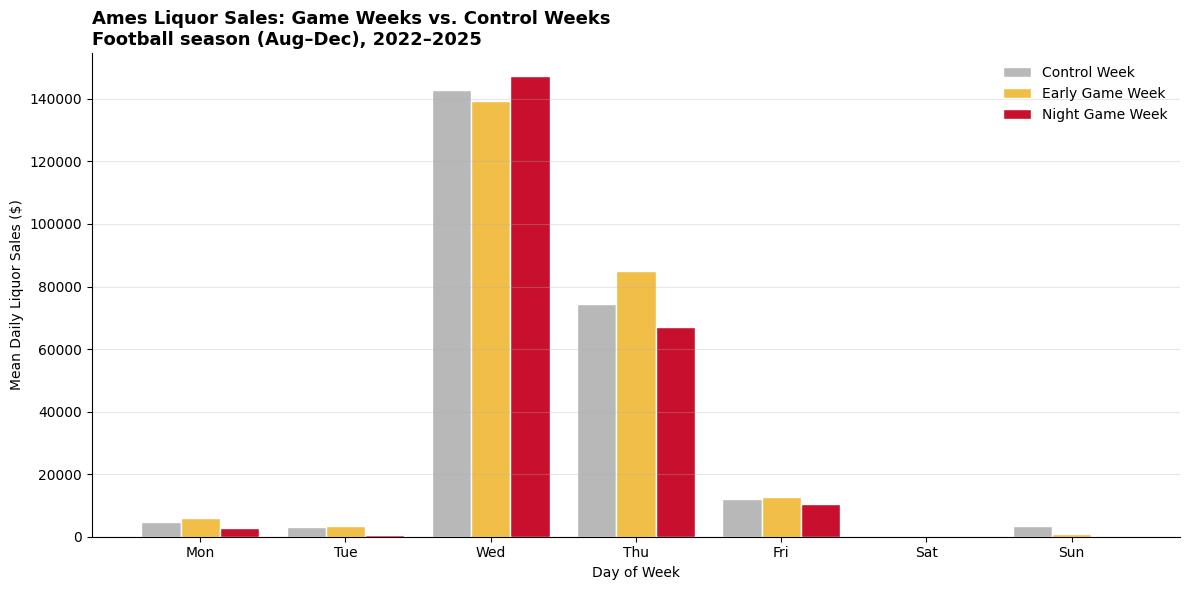

In [ ]:
n_pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",
                            values="n_days", observed=False).reindex(dow_order).fillna(0) # Add observed=False to silence FutureWarning
print("\nSample sizes (days per cell):")
print(n_pivot)

# Ensure the pivot table for mean_sales also includes all days of the week and fills missing values
pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",
                          values="mean_sales", observed=False).reindex(dow_order).fillna(0) # Add observed=False to silence FutureWarning

fig, ax = plt.subplots(figsize=(12, 6))

group_order = ["Control", "Early", "Night"]
colors = {"Control": "#B8B8B8", "Early": "#F1BE48", "Night": "#C8102E"}
labels = {"Control": "Control Week", "Early": "Early Game Week", "Night": "Night Game Week"}
width = 0.27
x = np.arange(len(dow_order))

for i, grp in enumerate(group_order):
    vals = (pivot[grp].values if grp in pivot.columns
            else np.zeros(len(dow_order)))
    offset = (i - 1) * width
    ax.bar(x + offset, vals, width, label=labels[grp],
           color=colors[grp], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean Daily Liquor Sales ($)")
ax.set_title("Ames Liquor Sales: Game Weeks vs. Control Weeks\n"
             "Football season (Aug–Dec), 2022–2025",
             fontsize=13, fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12514/2142570251.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_events = mean_sales_by_event.pivot_table(


Mean daily liquor sales ($) by Game Event:
GameEvent  Control Week  CyHawk Game  Regular Game
DayOfWeek                                         
Monday           4569.0          0.0        5780.0
Tuesday          2965.0       4682.0        2572.0
Wednesday      142691.0      85429.0      145699.0
Thursday        74569.0     255830.0       73748.0
Friday          11987.0      64012.0        5171.0
Saturday            0.0          0.0           0.0
Sunday           3319.0          0.0         797.0


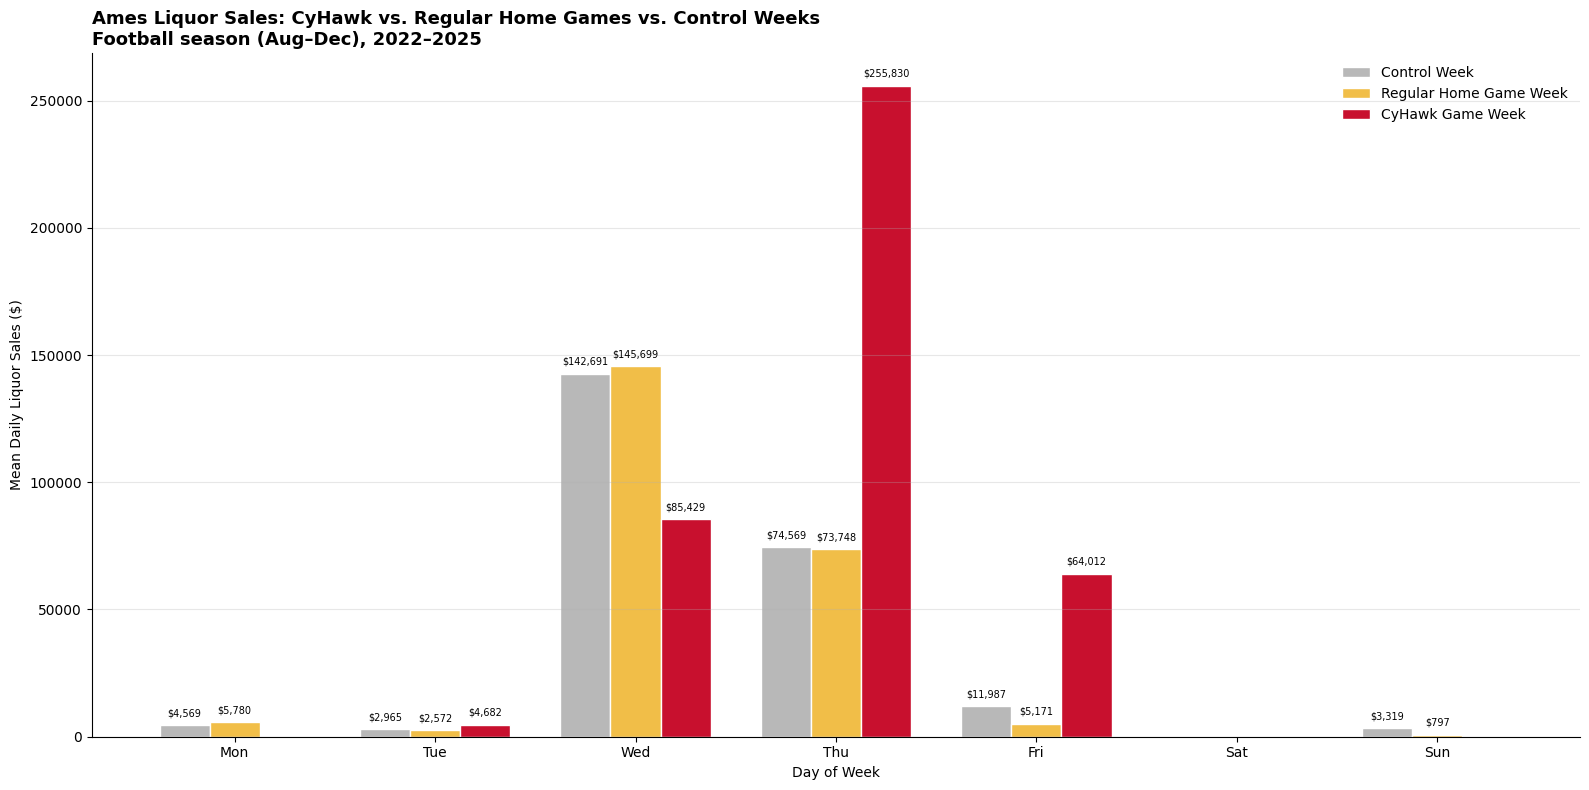

In [ ]:
df_merged["GameEvent"] = 'Control Week'
df_merged.loc[df_merged["is_cyhawk"], "GameEvent"] = 'CyHawk Game'
df_merged.loc[~df_merged["is_cyhawk"] & df_merged["is_game_week"], "GameEvent"] = 'Regular Game'

season_events = df_merged[df_merged["Month"].between(8, 12)].copy()

daily_sales_by_event = (
    season_events
    .groupby(["Date", "DayOfWeek", "GameEvent"], as_index=False)
    .agg(total_sales=("Sale (Dollars)", "sum"))
)

mean_sales_by_event = (
    daily_sales_by_event
    .groupby(["DayOfWeek", "GameEvent"], as_index=False)
    .agg(mean_sales=("total_sales", "mean"),
         n_days=("total_sales", "size"))
)

mean_sales_by_event["DayOfWeek"] = pd.Categorical(
    mean_sales_by_event["DayOfWeek"],
    categories=dow_order, ordered=True
)
mean_sales_by_event = mean_sales_by_event.sort_values("DayOfWeek")

pivot_events = mean_sales_by_event.pivot_table(
    index="DayOfWeek", columns="GameEvent", values="mean_sales"
)

# Fill NaN with 0 for consistent plotting, especially for Saturday
pivot_events = pivot_events.reindex(dow_order).fillna(0)

print("Mean daily liquor sales ($) by Game Event:")
print(pivot_events.round(0))

# Plotting
fig, ax = plt.subplots(figsize=(16, 8)) # Increased figure size

group_order_events = ["Control Week", "Regular Game", "CyHawk Game"]
colors_events = {
    "Control Week": "#B8B8B8",
    "Regular Game": "#F1BE48",
    "CyHawk Game": "#C8102E"
}
labels_events = {
    "Control Week": "Control Week",
    "Regular Game": "Regular Home Game Week",
    "CyHawk Game": "CyHawk Game Week"
}
width = 0.25
x = np.arange(len(dow_order))

for i, grp in enumerate(group_order_events):
    vals = pivot_events[grp].values if grp in pivot_events.columns else np.zeros(len(dow_order))
    offset = (i - 1) * width
    rects = ax.bar(x + offset, vals, width, label=labels_events[grp],
                   color=colors_events[grp], edgecolor="white")
    # Add data labels above each bar
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Only add label if value is greater than 0
            ax.annotate(f'${height:,.0f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # Increased vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=7, color='black') # Reduced font size

ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean Daily Liquor Sales ($)")
ax.set_title("Ames Liquor Sales: CyHawk vs. Regular Home Games vs. Control Weeks\n"\
             "Football season (Aug–Dec), 2022–2025",
             fontsize=13, fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Filter the DataFrame for Saturday transactions
saturday_transactions = df[df['DayOfWeek'] == 'Saturday']

# Display all Saturday transactions
display(saturday_transactions)

,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County Number,County,...,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons),DayOfWeek,DayOfWeekNum,YearWeek
53960,INV-59009500008,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,750,$6.50,$9.75,12,117.00,9,2.37,Saturday,5,2023-05-29/2023-06-04
53961,INV-59009500013,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,"1,000",$4.30,$6.45,12,77.40,12,3.17,Saturday,5,2023-05-29/2023-06-04
53962,INV-59009500018,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,750,$25.13,$37.70,6,226.20,4.5,1.18,Saturday,5,2023-05-29/2023-06-04
53963,INV-59009500014,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,"1,000",$7.87,$11.81,12,141.72,12,3.17,Saturday,5,2023-05-29/2023-06-04
53964,INV-59009500002,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,"1,750",$33.99,$50.99,3,152.97,5.25,1.38,Saturday,5,2023-05-29/2023-06-04
53965,INV-59009500009,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,750,$9.00,$13.50,12,162.00,9,2.37,Saturday,5,2023-05-29/2023-06-04
53966,INV-59009500001,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,"1,750",$33.99,$50.99,3,152.97,5.25,1.38,Saturday,5,2023-05-29/2023-06-04
53967,INV-59009500017,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,750,$5.25,$7.88,12,94.56,9,2.37,Saturday,5,2023-05-29/2023-06-04
53968,INV-59009500021,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,"1,750",$184.99,$277.49,4,1109.96,7,1.84,Saturday,5,2023-05-29/2023-06-04
53969,INV-59009500006,2023-06-03,4129,CYCLONE LIQUORS,626 LINCOLN WAY,AMES,50010,POINT (-93.618248037 42.021326987),NaN,STORY,...,750,$19.95,$29.93,6,179.58,4.5,1.18,Saturday,5,2023-05-29/2023-06-04


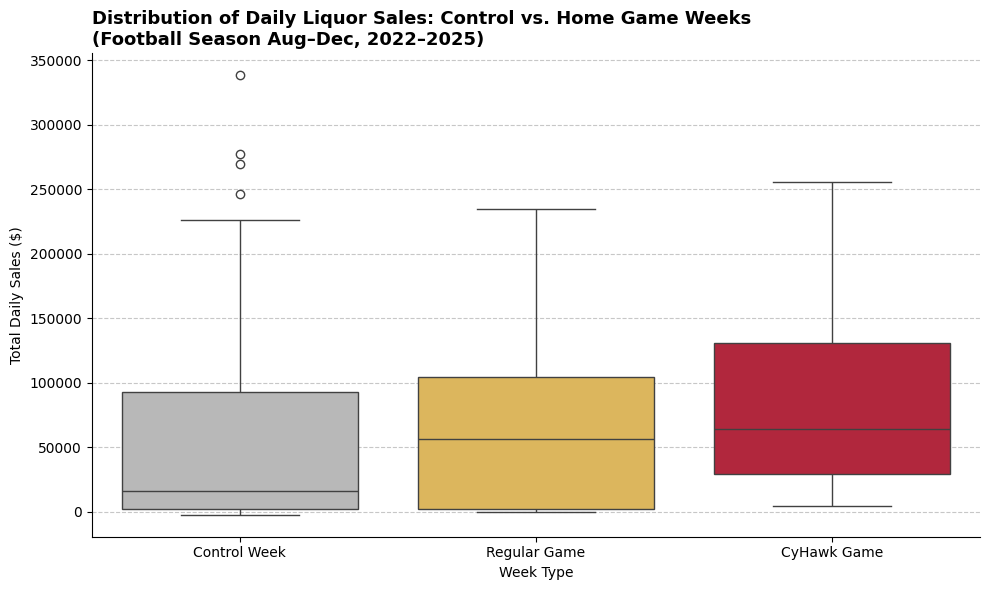

In [ ]:
df_merged["Month"] = df_merged["Date"].dt.month
df_merged["GameEvent"] = 'Control Week'
df_merged.loc[df_merged["is_cyhawk"], "GameEvent"] = 'CyHawk Game'
df_merged.loc[~df_merged["is_cyhawk"] & df_merged["is_game_week"], "GameEvent"] = 'Regular Game'

season_events = df_merged[df_merged["Month"].between(8, 12)].copy()

# Add a 'DateOnly' column to season_events to silence the FutureWarning about grouping
season_events['DateOnly'] = season_events['Date'].dt.date

daily_sales_for_boxplot = (
    season_events
    .groupby(['DateOnly', 'GameEvent'], as_index=False) # Group by the new column 'DateOnly'
    .agg(total_sales=("Sale (Dollars)", "sum"))
)

# Ensure the GameEvent categories are ordered for plotting
game_event_order = ['Control Week', 'Regular Game', 'CyHawk Game']
daily_sales_for_boxplot['GameEvent'] = pd.Categorical(
    daily_sales_for_boxplot['GameEvent'],
    categories=game_event_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 6))
# Modify boxplot call to silence the FutureWarning about palette and hue
sns.boxplot(x='GameEvent', y='total_sales', data=daily_sales_for_boxplot,
            palette={'Control Week': '#B8B8B8', 'Regular Game': '#F1BE48', 'CyHawk Game': '#C8102E'},
            order=game_event_order,
            hue='GameEvent', legend=False # Added hue and legend=False as suggested by the warning
           )

ax.set_title("Distribution of Daily Liquor Sales: Control vs. Home Game Weeks\n(Football Season Aug–Dec, 2022–2025)",
             fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Week Type")
ax.set_ylabel("Total Daily Sales ($)")
ax.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Control n=238, median=$21,282
Game    n=99, median=$45,892


/tmp/ipykernel_12514/575883560.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


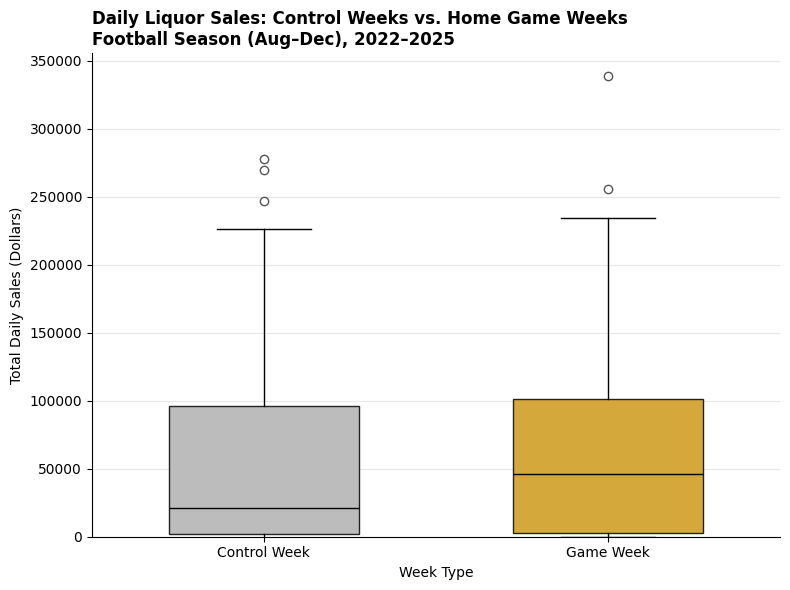

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load liquor data ---


# Clean Sale (Dollars) - it's a string with $ symbols
s = df["Sale (Dollars)"].astype(str).str.replace(r"[\$,]", "", regex=True)
neg = s.str.startswith("(") & s.str.endswith(")")
s = s.where(~neg, "-" + s.str.slice(1, -1))
df["Sale (Dollars)"] = s.astype(float)
df["Date"] = pd.to_datetime(df["Date"])
df["YearWeek"] = df["Date"].dt.to_period("W-SUN")

# --- Build game calendar (matches the slide) ---
games = pd.DataFrame([
    # 2022 (approximate kickoffs)
    ("2022-09-03", "Southeast Missouri", "~14:00", False, False),
    ("2022-09-10", "Iowa",               "~16:30", True,  False),
    ("2022-09-24", "Baylor",             "~14:00", False, True),
    ("2022-10-08", "Kansas State",       "~14:00", False, True),
    ("2022-10-15", "Texas",              "~14:00", False, True),
    ("2022-11-05", "Oklahoma State",     "~14:00", False, True),
    ("2022-11-26", "TCU",                "~14:00", False, True),
    # 2023
    ("2023-09-02", "Northern Iowa",      "13:00",  False, False),
    ("2023-09-09", "Iowa",               "14:30",  True,  False),
    ("2023-09-23", "Oklahoma State",     "~14:00", False, True),
    ("2023-10-07", "TCU",                "19:00",  False, True),
    ("2023-11-04", "Kansas",             "~14:00", False, True),
    ("2023-11-18", "Texas",              "19:00",  False, True),
    # 2024
    ("2024-08-31", "North Dakota",       "14:30",  False, False),
    ("2024-09-14", "Arkansas State",     "~14:00", False, False),
    ("2024-09-28", "Baylor",             "18:36",  False, True),
    ("2024-10-19", "UCF",                "18:30",  False, True),
    ("2024-11-02", "Texas Tech",         "~14:00", False, True),
    ("2024-11-16", "Cincinnati",         "~14:00", False, True),
    ("2024-11-30", "Kansas State",       "18:30",  False, True),
    # 2025
    ("2025-08-30", "South Dakota",       "~14:00", False, False),
    ("2025-09-06", "Iowa",               "11:00",  True,  False),
    ("2025-09-27", "Arizona",            "18:00",  False, True),
    ("2025-10-25", "BYU",                "14:30",  False, True),
    ("2025-11-01", "Arizona State",      "12:00",  False, True),
    ("2025-11-22", "TCU",                "~14:00", False, True),
], columns=["Date", "opponent", "kickoff", "is_cyhawk", "is_conference"])

games["Date"] = pd.to_datetime(games["Date"])
games["YearWeek"] = games["Date"].dt.to_period("W-SUN")
home_game_weeks = set(games["YearWeek"].unique())

# --- Filter to football season (Aug-Dec), all years ---
season = df[df["Date"].dt.month.between(8, 12)].copy()

# Aggregate to total daily sales
daily = season.groupby("Date", as_index=False)["Sale (Dollars)"].sum()
daily["YearWeek"] = daily["Date"].dt.to_period("W-SUN")
daily["WeekType"] = np.where(
    daily["YearWeek"].isin(home_game_weeks), "Game Week", "Control Week"
)

control = daily.loc[daily["WeekType"] == "Control Week", "Sale (Dollars)"].values
game    = daily.loc[daily["WeekType"] == "Game Week",    "Sale (Dollars)"].values

print(f"Control n={len(control)}, median=${np.median(control):,.0f}")
print(f"Game    n={len(game)}, median=${np.median(game):,.0f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(
    [control, game],
    labels=["Control Week", "Game Week"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color="black", linewidth=1),
    flierprops=dict(marker="o", markerfacecolor="none",
                    markeredgecolor="#555", markersize=6),
)
colors = ["#bcbcbc", "#d4a83a"]  # gray, gold
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_edgecolor("#222")

ax.set_title("Daily Liquor Sales: Control Weeks vs. Home Game Weeks\n"
             "Football Season (Aug–Dec), 2022–2025",
             fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Week Type", fontsize=10)
ax.set_ylabel("Total Daily Sales (Dollars)", fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()